# Coding Session 05 · Lab W5



## Today's plan

- Build and check reusable functions.
- Simulate an experiment with a nonzero effect; read confidence intervals.
- Vary sample size, estimate power/MDE, and calculate experiment cost.
- Try a brief AI setup and prompting exercise; retain DIME cleaning and plots as practice.



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


### 2. Functions

What’s a function?

A function is a named, reusable block of code. You give it inputs (parameters), it does some work, and it returns a result.

Why bother?

- Avoid copy-pasting the same code.
- Make your code easier to read, test, and fix.
- Give things good names so your future self understands them


In [2]:
def add_tax(amount, rate=0.0635):
    """Return total price after applying a tax rate (default 7%)."""
    total = amount * (1 + rate)
    return(total)

In [3]:
print(add_tax(100))
print(add_tax(100, 0.2))

106.35
120.0


### Read the function before trusting it

`def` names the function; `amount` and `rate` are inputs; `return` sends its result back. The implemented default above is **0.0635 (6.35%)**, while the docstring says 7%. Python follows the code, so `add_tax(100)` returns 106.35. The intended rate is a separate requirements question: do not silently select one based on an AI suggestion.



### Brief AI orientation: setup, logic, prompting

Open the available coding agent in the folder containing your saved exercise, or provide the small function directly. Confirm which files and Python runtime it can access; a local agent does not automatically share Colab's files or runtime. Use a copy and inspect changes before accepting them.

> Inspect `add_tax`. Input: an amount and an optional tax rate. Identify disagreements between code and documentation. Explain what `add_tax(100)` and `add_tax(100, 0.2)` currently return. Do not choose or change the intended default rate. Propose one small check and tell me what requirement must be clarified.

First predict both outputs yourself. Compare the agent's explanation with the executed outputs. Ask for a focused change only after the intended behavior is known. Later sessions use agents on longer workflows; here the target is understanding inputs, logic, constraints, and a check.


## One simulated experiment

This is **simulated practice data**, not a finding about a real campaign. Assume independent voters, equal random assignment, control turnout 40%, and a treatment effect of 3 percentage points. We generate binary outcomes under that nonzero effect. Unlike RI's null shuffles, a power simulation generates new outcomes in a world where the declared effect exists.


In [4]:
rng = np.random.default_rng(510)
n_per_group = 250
control = rng.binomial(1, 0.40, size=n_per_group)
treated = rng.binomial(1, 0.43, size=n_per_group)
pilot = pd.DataFrame({
    "assigned": np.repeat([0, 1], n_per_group),
    "turned_out": np.concatenate([control, treated]),
})
means = pilot.groupby("assigned")["turned_out"].mean()
estimate = means.loc[1] - means.loc[0]
se = np.sqrt(means.loc[1] * (1 - means.loc[1]) / n_per_group
             + means.loc[0] * (1 - means.loc[0]) / n_per_group)
print("Estimate (pp):", 100 * estimate)
print("Approximate 95% interval (pp):", 100 * np.array([estimate - 1.96 * se, estimate + 1.96 * se]))
smf.ols("turned_out ~ assigned", data=pilot).fit().summary()


Estimate (pp): -0.8000000000000007
Approximate 95% interval (pp): [-9.48366271  7.88366271]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             turned_out   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.03247
Date:                Tue, 15 Sep 2026   Prob (F-statistic):              0.857
Time:                        15:04:17   Log-Likelihood:                -358.21
No. Observations:                 500   AIC:                             720.4
Df Residuals:                     498   BIC:                             728.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4360      0.031     13.889      0.000       0.374       0.498
assigned      -0.0080      0.044     -0.180      0.857      -0.095       0.079
==============================================================================
Omnibus:                     2185.001   Durbin-Watson:                   2.005
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               83.430
Skew:                           0.275   Prob(JB):                     7.64e-19
Kurtosis:                       1.076   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Read the assignment row's coefficient, standard error, interval endpoints, and p-value. The OLS interval uses its fitted variance estimate, so it need not equal our simple binary-outcome approximation exactly. A wide interval including zero and useful positive effects is inconclusive. A 95% confidence procedure covers the true effect in about 95% of repeated samples under its assumptions; it does not give a probability for this fixed interval's parameter.



### Power using an inner randomization test

Generate an experiment, then test its sharp null by shuffling labels. Count how often the test rejects. The outer loop changes the data; the inner loop evaluates one dataset against its null. Modest repetition counts keep this demonstration manageable and leave Monte Carlo noise; use more repetitions for a final design.


In [5]:
def power_with_ri(n_per_group, true_effect, repetitions=150, shuffles=99, seed=511):
    rng = np.random.default_rng(seed)
    assigned = np.repeat([0, 1], n_per_group)
    detected = []
    for repetition in range(repetitions):
        outcomes = np.concatenate([
            rng.binomial(1, 0.40, n_per_group),
            rng.binomial(1, 0.40 + true_effect, n_per_group),
        ])
        observed = outcomes[assigned == 1].mean() - outcomes[assigned == 0].mean()
        extreme = 0
        for shuffle in range(shuffles):
            fake_assigned = rng.permutation(assigned)
            gap = outcomes[fake_assigned == 1].mean() - outcomes[fake_assigned == 0].mean()
            extreme += abs(gap) >= abs(observed)
        p_value = (1 + extreme) / (1 + shuffles)
        detected.append(p_value <= 0.05)
    return np.mean(detected)

power_with_ri(250, 0.03)


np.float64(0.15333333333333332)

### A faster power approximation for planning

For a grid of sample sizes, simulate independent binomial counts and use a two-sided pooled normal test. A binomial count is the sum of independent binary outcomes, so this saves memory without changing the outcome-generating model. The normal test approximates RI; it is not the same procedure, especially with small samples. Power depends on the effect, baseline rate, allocation, test, and independence assumptions.


In [6]:
def simulated_power(n_total, effect, repetitions=4000, baseline=0.40, seed=512):
    if n_total < 4 or n_total % 2:
        raise ValueError("Use an even total sample size of at least four.")
    if not 0 < baseline < 1 or not 0 <= baseline + effect <= 1:
        raise ValueError("Outcome probabilities must lie between zero and one.")
    rng = np.random.default_rng(seed)
    n = n_total // 2
    control_rate = rng.binomial(n, baseline, repetitions) / n
    treated_rate = rng.binomial(n, baseline + effect, repetitions) / n
    pooled = (control_rate + treated_rate) / 2
    se_null = np.sqrt(2 * pooled * (1 - pooled) / n)
    reject = np.abs(treated_rate - control_rate) > 1.96 * se_null
    return reject.mean()

power_table = pd.DataFrame({"n_total": [500, 1000, 2000, 5000, 10000, 20000]})
power_table["power"] = [simulated_power(n, 0.03) for n in power_table["n_total"]]
power_table["mc_se"] = np.sqrt(power_table["power"] * (1 - power_table["power"]) / 4000)
power_table


,n_total,power,mc_se
0,500,0.10075,0.004759
1,1000,0.15775,0.005763
2,2000,0.26375,0.006968
3,5000,0.57275,0.007822
4,10000,0.85900,0.005503
5,20000,0.99275,0.001341


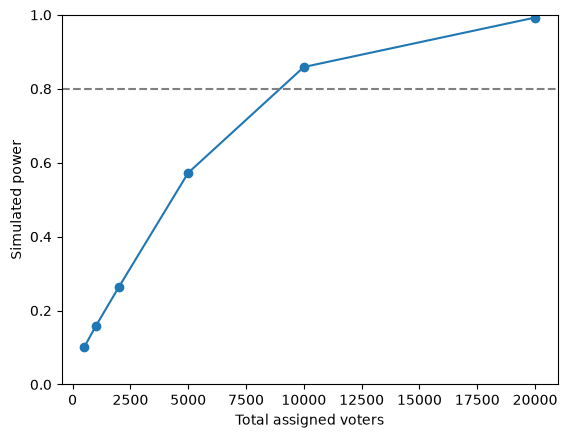

Smallest effect on this grid reaching 80% power (pp): 13.0


,effect,power
0,0.01,0.05250
1,0.02,0.07325
2,0.03,0.10075
3,0.04,0.14650
4,0.05,0.20775
5,0.06,0.27775
6,0.07,0.36750
7,0.08,0.44025
8,0.09,0.53225
9,0.10,0.61075


In [7]:
plt.plot(power_table["n_total"], power_table["power"], marker="o")
plt.axhline(0.80, color="gray", linestyle="--")
plt.xlabel("Total assigned voters")
plt.ylabel("Simulated power")
plt.ylim(0, 1)
plt.show()

effect_grid = np.arange(0.01, 0.161, 0.01)
mde_table = pd.DataFrame({"effect": effect_grid})
mde_table["power"] = [simulated_power(500, effect) for effect in effect_grid]
qualifying = mde_table.loc[mde_table["power"] >= 0.80, "effect"]
print("Smallest effect on this grid reaching 80% power (pp):",
      100 * qualifying.iloc[0] if len(qualifying) else "not reached")
mde_table


A grid-based MDE is approximate: refine the grid and increase repetitions around its crossing. Check simulated power at effect zero as a false-positive diagnostic. Small effects can matter substantively while remaining hard to detect in a small experiment.



### From sample size to experiment cost

Assume the assigned treatment is a door-knock attempt, independent assignment is by household, and one listed record represents one attempted household. For this exercise only, a successful conversation costs 24 USD and the contact rate is 25%; that implies 6 USD per attempt under the stated accounting convention. Buy attempts for the treatment group, not the entire sample. Overheads are additional. If the effect is per actual contact instead of per assignment, it is not the same effect used in the power calculation.


In [8]:
eligible_designs = power_table.loc[power_table["power"] >= 0.80]
chosen_n = int(eligible_designs["n_total"].iloc[0]) if len(eligible_designs) else None
cost_per_conversation = 24
contact_rate = 0.25
cost_per_attempt = cost_per_conversation * contact_rate
if chosen_n is not None:
    n_treated = chosen_n // 2
    study_cost = n_treated * cost_per_attempt
    print("Chosen grid sample size:", chosen_n)
    print("Treatment attempts:", n_treated)
    print("Illustrative study cost (USD):", study_cost)
else:
    print("Extend the sample-size grid before proposing a study budget.")


Chosen grid sample size: 10000
Treatment attempts: 5000
Illustrative study cost (USD): 30000.0


## Practice — write a binomial simulation from scratch

Suppose a mock campaign team reports success in 18 of 30 conversations. This is a **simulation exercise**, not measured persuasion. Assume each conversation independently succeeds with probability 0.45. Write code to generate 30 binary outcomes, count successes, and repeat 2,000 times using a list and a loop. Compute the fraction with at least 18 successes. Use a seed and compare your answer with the direction you expected. Do not paste the power function: write the data generation, storage, and comparison yourself.


In [9]:
# Your code: generate, count, append, repeat, and calculate the tail fraction.


**Practice — modify the design:** change the assumed effect to 0.02, find the first sample-size grid point reaching 80% power, and write its treatment-group cost calculation. If none qualifies, extend the grid. Explain what a null result would and would not rule out.

**Additional practice:** compare power at effect zero with the nominal 5% false-positive rate; increase repetitions to distinguish simulation noise from a systematic problem. Explain why household clustering or lower contact rates could change a real design's power and cost. Use the retained DIME section below to practice cleaning and figure interpretation.



## Additional practice: DIME cleaning, summaries, and visualization

These candidate-year observations support descriptive fundraising comparisons, not a randomized estimate of the return to a campaign tactic. All original cleaning and plotting topics are retained here.


### 0.1 Environment preparation

We begin by loading the libraries we’ll need. In Python, libraries are like toolkits: they extend the language with specialized functions.

- **pandas (pd)** is our main tool for working with tabular data. It introduces the DataFrame, which lets us manipulate datasets in a way that feels natural if you’ve used Excel or R.
- **NumPy (np)** provides the numerical backbone. It gives us arrays and fast mathematical functions, which pandas actually uses under the hood.
- **Seaborn (sns)** builds on top of Matplotlib to create a vast range of plots and visualization.


### 0.2 Reading Dataset


The **Database on Ideology, Money in Politics, and Elections (DIME), Version 4.0** provides a comprehensive record of campaign finance activity in the United States between **1979 and 2024**. It contains more than **850 million itemized contributions** from individuals and organizations to candidates, parties, and political committees at the federal, state, and local levels (Bonica, 2024).

DIME is organized into two primary components:

* **Candidate/Recipient Database** – includes information on candidates and committees, such as names, party affiliation, state, office sought, district, gender, incumbency status, fundraising totals, election outcomes, and multiple measures of ideology.
* **Contributor Database** – contains records on donors, both individuals and organizations, with demographic details, contribution histories, and ideological scores.

For this coding session, we use a **subset of the candidate/recipient database** covering the **2020 and 2024 federal elections** with some small modifications.

You can access the complete dataset here: [DIME 4.0 – Stanford University Libraries](http://data.stanford.edu/dime).

**Reference:**
Bonica, Adam. 2024. *Database on Ideology, Money in Politics, and Elections: Public version 4.0* [Computer file]. Stanford, CA: Stanford University Libraries. Available at: [http://data.stanford.edu/dime](http://data.stanford.edu/dime).

#### Codebook


| Variable                | Description |
|--------------------------|-------------|
| **lname**               | Last name of the candidate/recipient. |
| **fname**               | First name of the candidate/recipient. |
| **party**               | Party of candidate/recipient (100 = Democrat, 200 = Republican, 328 = Independent). |
| **state**               | Two-letter state abbreviation. |
| **seat**                | Office sought (e.g., `federal:house`, `federal:senate`, `federal:president`, `state:governor`, etc.). |
| **district**            | District code: two-letter state code followed by congressional district number. For Senate candidates, “S” plus the year of the seat’s election. |
| **ico.status**          | Incumbency status (`I` = Incumbent, `C` = Challenger, `O` = Open Seat Candidate, blank = not up for election). |
| **cand.gender**         | Candidate gender coding (based on Census first-name ratios and gendered titles). |
| **recipient.cfscore.dyn** | Period-specific estimates of ideology. Candidate/recipient scores are re-estimated each cycle while holding contributor scores constant. |
| **contributor.cfscore** | Estimated ideology of the candidate/recipient based on their **personal donations** to other candidates/recipients. |
| **num.givers.total**    | Number of distinct donors that gave to the candidate/recipient over their career. |
| **total.receipts**      | Sum total of contributions raised during an election cycle. |
| **total.disbursements**      | Sum total of disbursements spent during an election cycle. |
| **prim.vote.pct**       | FEC-reported vote share (%) in the primary election (federal congressional candidates only). |
| **pwinner**             | Primary election outcome (`W` = won; `L` = lost). Federal congressional candidates only. |
| **gen.vote.pct**        | FEC-reported vote share (%) in the general election. |
| **gwinner**             | General election outcome (`W` = won; `L` = lost). Federal candidates coded from FEC, state candidates from NIMSP. |



In [10]:
from pathlib import Path

# Works from a session folder, the repository root, or a fresh Colab notebook.
data_candidates = [
    Path("data/dime_candidates_2020_2024.csv"),
    Path("wk05_power_and_nulls/data/dime_candidates_2020_2024.csv"),
    Path("../wk05_power_and_nulls/data/dime_candidates_2020_2024.csv"),
]
data_path = next((p for p in data_candidates if p.exists()), None)
data_url = "https://raw.githubusercontent.com/albertostefanelli/DSPC_coding_sessions/master/wk05_power_and_nulls/data/dime_candidates_2020_2024.csv"
df_bonica = pd.read_csv(data_path if data_path is not None else data_url)
df_bonica.head()


,election,lname,fname,party,state,seat,district,ico.status,cand.gender,recipient.cfscore.dyn,contributor.cfscore,num.givers.total,total.receipts,total.disbursements,prim.vote.pct,pwinner,gen.vote.pct,gwinner
0,fd2020,petrilli,george,100,IL,federal:house,IL18,C,M,-1.056,-0.913,17,16219.62,8270.2 USD,0.001,W,29.590000,L
1,fd2020,chambers,gary,100,LA,federal:house,LA02,C,M,-1.208,-2.070,21959,106626.67 dollars,28800.99,NaN,NaN,NaN,NaN
2,fd2020,finley,christopher,100,TN,federal:house,TN06,C,M,-0.854,NaN,2,0,0,NaN,NaN,24.559492,L
3,fd2020,hamilton,wendy,100,DC,federal:house,DC01,C,F,-0.837,NaN,387,5163.66 USD,2319.08,NaN,NaN,NaN,NaN
4,fd2020,n,mckayla,100,MD,federal:house,MD05,C,F,-1.125,-1.131,8154,0,0,NaN,NaN,NaN,NaN


### 1. Advanced text cleaning with .replace

We’re building a clean text pipeline for 3 columns: total.receipts, total.disbursements, and ico.status. Our goal is to compare expediture levels by candidacy status: I (Incumbent), C (Challenger), and O (Open seat). Before transforming anything, we should verify data types and surface obvious issues—text fields often mix strings, missing values, stray symbols, or even numerics. After consulting the codebook, we’ll inspect the dataset’s structure to confirm that total.receipts is truly numeric and that ico.status contains only the expected codes. In pandas, we can use `.dtypes`, and some quick diagnostics (i.e., .value_counts(dropna=False)) to catch type problems and unexpected categories, then standardize and coerce as needed.


In [11]:
print(df_bonica.dtypes)
print(df_bonica["ico.status"].value_counts(dropna=False))
print(df_bonica["total.receipts"].head())

election                     str
lname                        str
fname                        str
party                      int64
state                        str
seat                         str
district                     str
ico.status                   str
cand.gender                  str
recipient.cfscore.dyn    float64
contributor.cfscore      float64
num.givers.total           int64
total.receipts               str
total.disbursements          str
prim.vote.pct            float64
pwinner                      str
gen.vote.pct             float64
gwinner                      str
dtype: object
ico.status
C      1657
I       596
O       454
0        50
NaN       2
Name: count, dtype: int64
0             16219.62
1    106626.67 dollars
2                    0
3          5163.66 USD
4                    0
Name: total.receipts, dtype: str


It looks like we have some messy text in both `ico.status` and `total.receipts`. To clean these columns efficiently, we can use the **`.replace()`** method in pandas. This function is very flexible because it allows us to change values either by matching exact text or by using patterns (regular expressions).

There are two main ways we can use `.replace()`:

* **Pattern matching with regex**

  * `.replace(pattern, repl, regex=True)`
  * This lets us use regular expressions (regex) to match and replace flexible text patterns, not just exact words. For example, it’s useful when values have multiple variations or symbols we want to standardize.

* **Dictionary mapping**

  * `.replace({'OLD': 'NEW', ...})`
  * This is the simplest case: you directly map old values to new ones. It’s useful for standardizing known categories (e.g., turning `"O"` into `"Open Seat"`).

We’ll begin by looking at the **first approach** with `regex=True`. This is especially powerful when the text we want to clean is inconsistent—for instance, numbers followed by symbols like `"USD"`, a currency symbol, or `"dollars"`. Using regex allows us to target the pattern itself rather than writing a rule for every single variant.


In [12]:
df_bonica['total.receipts.clean'] = (
    df_bonica['total.receipts']
      .astype(str)
      .replace('dollars', '', regex=True)
)

df_bonica[['total.receipts.clean','total.receipts']].head()

,total.receipts.clean,total.receipts
0,16219.62,16219.62
1,106626.67,106626.67 dollars
2,0,0
3,5163.66 USD,5163.66 USD
4,0,0


Next, we will take a look at dictionary mapping with `.replace()`. This approach is straightforward and works best when we already know the exact values we want to change.

This method is especially useful for categorical variables or labels that appear in a small set of known forms. For example, if a column contains "Dem", "DEM", and "Democrat", we can map all of them to "Democratic". Similarly, we can standardize "Rep" and "Republican Party" to "Republican".


In [13]:
df_bonica['ico.status.clean'] = df_bonica['ico.status'].replace({
        "O": "open_seat",
        "0": "open_seat",
        "C": "challenger",
        "I": "incumbent",
    })

print(df_bonica["ico.status.clean"].value_counts(dropna=False))


ico.status.clean
challenger    1657
incumbent      596
open_seat      504
NaN              2
Name: count, dtype: int64


##### **Intramezzo: Dictionary**

- Dictionary = lookup table. Think: “When I see this code, give me that label.”
- It stores key to value pairs (e.g., I → incumbent).
- Keys are unique (usually strings or ints); values can be anything.
- Use it to translate or standardize codes fast.

In [14]:
d = {'I': 'incumbent',
     'C': 'challenger',
     'O': 'open_seat',
     '0': 'open_seat',
     1  : 'open_but_close'}
print(d)

{'I': 'incumbent', 'C': 'challenger', 'O': 'open_seat', '0': 'open_seat', 1: 'open_but_close'}


In [15]:
def clean_dollars(s):
    """Remove documented currency labels, punctuation, and whitespace."""
    text = s.astype("string")
    text = text.str.replace(chr(36), "", regex=False)
    text = text.str.replace("USD|usd|dollars", "", regex=True)
    text = text.str.replace(",", "", regex=False).str.replace(r"\s+", "", regex=True)
    # Raise on unexpected text; genuine missing values remain missing.
    return pd.to_numeric(text, errors="raise").astype(float)


How the cleaning function works: keep missing values using pandas' string dtype, remove the documented currency marker (`chr(36)`), remove currency words, commas, and whitespace, then convert to numeric. Unexpected text raises an error instead of silently becoming missing. Inspect and document unexpected values before adding another cleaning rule.


In [16]:
df_bonica['total.receipts.clean'] = clean_dollars(df_bonica['total.receipts'])
df_bonica['total.disbursements.clean'] = clean_dollars(df_bonica['total.disbursements'])

print(df_bonica[['total.receipts.clean','total.receipts']].head())
print(df_bonica[['total.receipts.clean','total.receipts']].dtypes)

   total.receipts.clean     total.receipts
0              16219.62           16219.62
1             106626.67  106626.67 dollars
2                  0.00                  0
3               5163.66        5163.66 USD
4                  0.00                  0
total.receipts.clean    float64
total.receipts              str
dtype: object


### 3. Quick summaries

Now let's the back to our main task and let's use the clean columns to get some interesting numbers. Let's calculate the average `total.receipts`. We can do so using the numpy package and the function np.average.

In [17]:
print("Total receipts across 2020 & 2024: USD", round(np.sum(df_bonica["total.receipts.clean"]), 0))
print("Average raised per candidate USD", round(np.mean(df_bonica["total.receipts.clean"]), 0))

Total receipts across 2020 & 2024: USD 6315686940.0
Average raised per candidate USD 2289122.0


Let's break this down by year to see where there is been an increase or the total ammount of money received by the candidates stayed the same.

In [18]:
summary_year = (
    df_bonica.groupby("election")["total.receipts.clean"]
       .agg(total="sum", average="mean", n="count")
       .round(2)
)
summary_year

,total,average,n
election,,,
fd2020,3.942288e+09,2752994.27,1432
fd2024,2.373399e+09,1788544.95,1327


Now let’s repeat the visualization, this time breaking it down by the candidate’s incumbent status. This returns us to our **core question**: to see whether most campaign money comes from incumbents or from challengers.

In [19]:
summary_ico_status = (
    df_bonica.groupby("ico.status.clean")["total.receipts.clean"]
       .agg(total="sum", average="mean", n="count")
       .round(2)
)
summary_ico_status

,total,average,n
ico.status.clean,,,
challenger,3.416315e+09,2061747.24,1657
incumbent,2.395377e+09,4019088.49,596
open_seat,5.001150e+08,992291.70,504


### 4. Visualise data using Seaborn

Data visualization helps us see patterns, trends, and relationships that might be hidden in raw numbers. In Python, Seaborn is a powerful library built on top of Matplotlib that makes it easy to create clear and attractive statistical graphics. With just a few lines of code, we can generate plots such as histograms, scatter plots, and bar charts that summarize and explain our data.

**IMPORTANT:** Seaborn can feel a bit tricky at first. If you find it challenging, don’t worry —-- we’ve prepared a Seaborn mini-lab to help you get started. You can find it on Prof. Kalla’s GitHub: [Seaborn Mini-Lab](https://githubtocolab.com/joshuakalla/data_science_campaigns/blob/master/seaborn/seaborn_minilab.ipynb).


Let's start with a very simple histogram.


<Axes: xlabel='total.receipts.clean', ylabel='Count'>

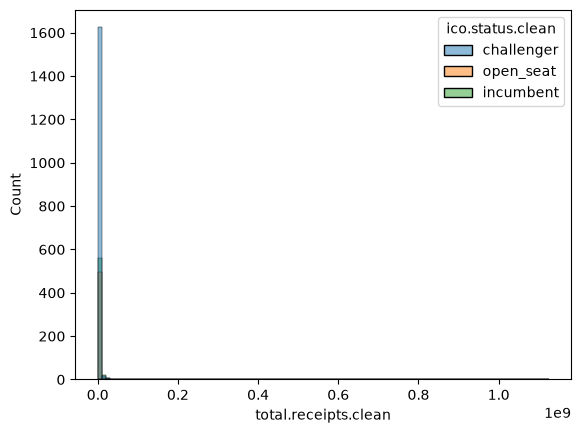

In [20]:
sns.histplot(                 # Call Seaborn's histogram function
    data=df_bonica,           # Use the DataFrame 'df_bonica' as the source of the data
    x='total.receipts.clean', # Plot the variable 'total.receipts.clean' on the x-axis
    hue='ico.status.clean'    # Color (differentiate) the bars by 'ico.status.clean' groups
)

Right now, the plot is pretty hard to read. Let’s improve the viz.

* Expressing `total.receipts.clean` in **millions of dollars** (so the numbers are easier to interpret).
* Choosing a more appropriate number of **bins** to balance detail and clarity.
* Excluding the **long tail** of extreme values in `total.receipts.clean` that distort the visualization.
* Use `element='step'` argument to outline the bars instead of fill them. This makes them easier to see if they overlap.
* Add clear labels to the x-axis and y-axis, and include a descriptive title so the plot is easy to interpret.



In [21]:
# total.receipts in millions
df_bonica["total.receipts.clean.m"] = df_bonica["total.receipts.clean"]/1000000

In [22]:
# A display cutoff, not a claim that skewed receipts follow a normal distribution.
plot_cutoff = df_bonica["total.receipts.clean.m"].quantile(0.95)
print("95th-percentile display cutoff (million USD):", plot_cutoff)


95th-percentile display cutoff (million USD): 6.2257341109999995


In [23]:
df_bonica_subset = df_bonica.loc[df_bonica["total.receipts.clean.m"] <= plot_cutoff].copy()
print("Rows above display cutoff:", int((df_bonica["total.receipts.clean.m"] > plot_cutoff).sum()))


Rows above display cutoff: 138


[Text(0.5, 0, 'Total receipts (million USD)'),
 Text(0, 0.5, 'Count'),
 Text(0.5, 1.0, 'Receipts by incumbency status (bottom 95% of observed values)')]

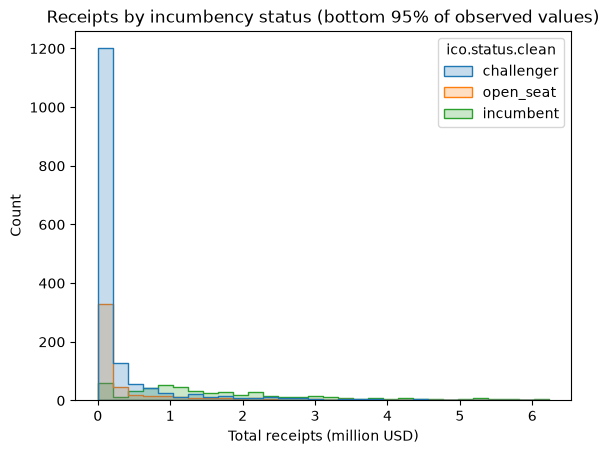

In [24]:
sns_hist = sns.histplot(data=df_bonica_subset,
                        x='total.receipts.clean.m',
                        hue='ico.status.clean',
                        bins=30,
                        element='step')

sns_hist.set(xlabel='Total receipts (million USD)',
             ylabel='Count',
             title='Receipts by incumbency status (bottom 95% of observed values)')

**Bins:**  When you make a histogram, you’re essentially chopping the range of your variable (here, total.receipts.clean) into intervals (the bins). Each bin covers a slice of values (for example, 0–1 million, 1–2 million, etc.), and the height of the bar shows how many observations fall into that slice.

- More bins → narrower intervals: more detail, but the plot can look noisy.
- Fewer bins → wider intervals: smoother plot, but you lose details.
